In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('df_pca.csv')

In [14]:
df.head()

,Week_End,Week_Start_Fri,Week_Label,Weekly_Rank,id,Title,Artists_All,Weekly_Points,Streams,Days_Charted,...,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,Song_URL,PC1,PC2,PC3,PC4
0,2017/1/6,2016/12/31,2016-12-31 → 2017-01-06,1,5aAx2yezTd8zXrkmtKl66Z,Starboy,"The Weeknd, Daft Punk",1198,NaN,6.0,...,-7.028,0.282,0.165,0.0,0.535,https://open.spotify.com/track/5aAx2yezTd8zXrk...,0.093323,1.486236,0.479126,-1.053577
1,2017/1/6,2016/12/31,2016-12-31 → 2017-01-06,2,7BKLCZ1jbUBVqRi2FVlTVw,Closer,"The Chainsmokers, Halsey",1192,NaN,6.0,...,-5.599,0.034,0.414,0.0,0.661,https://open.spotify.com/track/7BKLCZ1jbUBVqRi...,-0.071947,0.215021,-0.988435,0.958771
2,2017/1/6,2016/12/31,2016-12-31 → 2017-01-06,3,5knuzwU65gJK7IF5yJsuaW,Rockabye (feat. Sean Paul & Anne-Marie),Clean Bandit,1185,NaN,6.0,...,-4.068,0.052,0.406,0.0,0.742,https://open.spotify.com/track/5knuzwU65gJK7IF...,1.040625,-0.218344,-0.742067,0.919837
3,2017/1/6,2016/12/31,2016-12-31 → 2017-01-06,4,4pdPtRcBmOSQDlJ3Fk945m,Let Me Love You,"DJ Snake, Justin Bieber",1176,NaN,6.0,...,-5.309,0.058,0.078,0.0,0.142,https://open.spotify.com/track/4pdPtRcBmOSQDlJ...,-0.361769,-1.774901,0.536522,-1.350242
4,2017/1/6,2016/12/31,2016-12-31 → 2017-01-06,5,3NdDpSvN911VPGivFlV5d0,I Don't Wan Live Forever (Fifty Shades Darker)...,"ZAYN, Taylor Swift",1170,NaN,6.0,...,-8.374,0.059,0.063,0.0,0.086,https://open.spotify.com/track/3NdDpSvN911VPGi...,-1.202927,-0.118441,0.343824,-0.897204


## 1.Statistical Tests (H1)

In [2]:
pre = df[df['Stage'] == 'Stage 1 (2017-2019)']
pandemic = df[df['Stage'] == 'Stage 2 (2020-2022)']
post = df[df['Stage'] == 'Stage 3 (2023-2025)']

In [3]:
print('Pre', len(pre))
print('Pre', len(pandemic))
print('Post', len(post))

Pre 31217
Pre 31425
Post 29067


In [4]:
pcs = ['PC1', 'PC2', 'PC3', 'PC4']
pc_labels = {
    'PC1': 'PC1 Intensity',
    'PC2': 'PC2 Vocal Style',
    'PC3': 'PC3 Instrumentalness',
    'PC4': 'PC4 Positive Vocal'
}

In [5]:
means = pd.DataFrame({
    'Pre (2017–2019)': pre[pcs].mean(),
    'Pandemic (2020–2022)': pandemic[pcs].mean(),
    'Post (2023–2025)': post[pcs].mean()})
print(means)

     Pre (2017–2019)  Pandemic (2020–2022)  Post (2023–2025)
PC1         0.175224              0.015000         -0.204402
PC2         0.172455              0.084421         -0.276481
PC3         0.045576             -0.064656          0.020953
PC4        -0.152947             -0.006900          0.171719


###  H1: Are there significant differences between Pre and Pandemic?

In [8]:
t1, p1 = stats.ttest_ind(pre['PC1'], pandemic['PC1'])
t2, p2 = stats.ttest_ind(pre['PC2'], pandemic['PC2'])
t3, p3 = stats.ttest_ind(pre['PC3'], pandemic['PC3'])
t4, p4 = stats.ttest_ind(pre['PC4'], pandemic['PC4'])
print("H1: Pre-pandemic vs Pandemic (t-test)")
print(f"PC1 Intensity:        t={t1}, p={p1}")
print(f"PC2 Vocal Style:      t={t2}, p={p2}")
print(f"PC3 Instrumentalness: t={t3}, p={p3}")
print(f"PC4 Positive Vocal:   t={t4}, p={p4}")

H1: Pre-pandemic vs Pandemic (t-test)
PC1 Intensity:        t=13.657778622567443, p=2.0871548636705015e-42
PC2 Vocal Style:      t=9.979131938253126, p=1.958459674774095e-23
PC3 Instrumentalness: t=16.144897825216933, p=1.6198955120295308e-58
PC4 Positive Vocal:   t=-19.941470110074007, p=3.3431392669166765e-88


All 4 PCs show extremely small p-values, indicating statistically significant differences in audio feature patterns between the pre-pandemic and pandemic periods. 
H1 is supported.

## 2.K-means Clustering (H2)

We apply K-means clustering on 4 PCA-reduced components to group songs into representative audio profiles. The optimal number of clusters is selected using the Elbow Method and Silhouette Score.

In [15]:
data_prepared = df[['PC1', 'PC2', 'PC3', 'PC4']]
data_prepared.head()

,PC1,PC2,PC3,PC4
0,0.093323,1.486236,0.479126,-1.053577
1,-0.071947,0.215021,-0.988435,0.958771
2,1.040625,-0.218344,-0.742067,0.919837
3,-0.361769,-1.774901,0.536522,-1.350242
4,-1.202927,-0.118441,0.343824,-0.897204


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

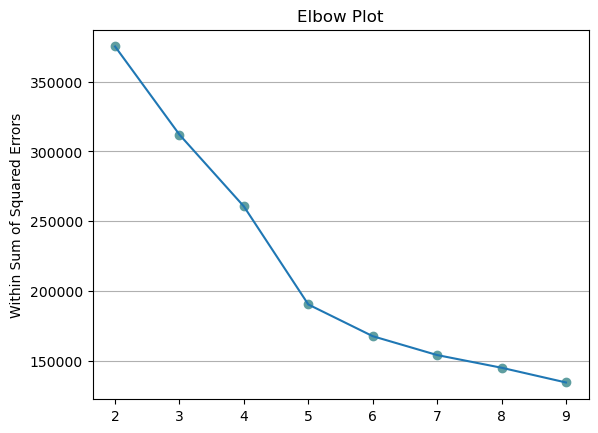

In [17]:
within_sse = []
sil = []
k_values = range(2,10)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=617)
    kmeans.fit(data_prepared)
    within_sse.append(kmeans.inertia_)
    sil.append(silhouette_score(X = data_prepared, labels = kmeans.fit_predict(data_prepared)))

plt.scatter(k_values, within_sse, c = 'cadetblue')
plt.plot(k_values, within_sse)
plt.title('Elbow Plot')
plt.ylabel('Within Sum of Squared Errors')
plt.grid(axis = 'y')
plt.show()

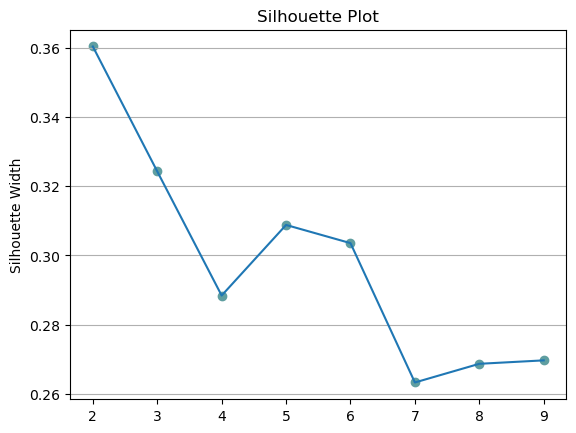

In [18]:
plt.scatter(k_values, sil, c='cadetblue')
plt.plot(k_values, sil)
plt.title('Silhouette Plot')
plt.ylabel('Silhouette Width')
plt.grid(axis='y')
plt.show()

The Elbow Plot shows a notable bend at K=5, while the Silhouette Plot peaks at K=2 but drops sharply afterward. Considering both statistical guidance and interpretability, we select **K=4** as it balances cluster separation with meaningful musical profiles.

### Fit K-means with K=4

In [37]:
km = KMeans(n_clusters=4, random_state=617, init='k-means++')
km_clusters = km.fit_predict(data_prepared)

df = df.assign(km_clusters=km_clusters)
df.km_clusters = df.km_clusters.astype('category')
df.km_clusters.value_counts()

km_clusters
3    35535
0    28368
2    14288
1    13518
Name: count, dtype: int64

In [32]:
features = ['Danceability', 'Energy', 'Loudness', 'Speechiness',
            'Acousticness', 'Instrumentalness', 'Valence']

df.groupby('km_clusters')[features].mean().round(2).T

km_clusters,0,1,2,3
Danceability,0.64,0.75,0.57,0.50
Energy,0.64,0.73,0.42,0.44
Loudness,-6.35,-4.87,-9.12,-15.04
Speechiness,0.13,0.09,0.07,0.07
Acousticness,0.15,0.17,0.64,0.33
Instrumentalness,0.00,0.00,0.01,0.60
Valence,0.36,0.69,0.37,0.25


### Name the Clusters

Based on the mean audio features within each cluster, we assign the following interpretive labels:

Cluster 0 has relatively high energy (0.67) and loudness (-5.99), but the lowest valence among all clusters (0.36), suggesting intense but emotionally dark tracks. Label it "**High-Energy Dark**".

Cluster 1 has the highest speechiness (0.28) and danceability (0.76), which strongly indicates rap and hip-hop dominated content. Label it "**Rap / Hip-Hop**".

Cluster 2 has the highest acousticness (0.64) and the lowest energy (0.40) and loudness (-9.95), pointing to soft, stripped-down songs. Label it "**Acoustic Ballad**".

Cluster 3 is the largest group with the highest energy (0.72), loudness (-4.92), and valence (0.70), fitting the profile of cheerful mainstream dance pop. Label it "**Upbeat Dance Pop**".

In [22]:
cluster_names = {
    0: 'High-Energy Dark',
    1: 'Rap / Hip-Hop',
    2: 'Acoustic Ballad',
    3: 'Upbeat Dance Pop'
}

df['cluster_name'] = df['km_clusters'].map(cluster_names)
df['cluster_name'].value_counts()

cluster_name
Upbeat Dance Pop    35535
High-Energy Dark    28368
Acoustic Ballad     14288
Rap / Hip-Hop       13518
Name: count, dtype: int64

In [23]:
stage_cluster = df.groupby(['Stage', 'cluster_name']).size().unstack(fill_value=0)
stage_cluster_pct = stage_cluster.div(stage_cluster.sum(axis=1), axis=0).round(4) * 100
stage_cluster_pct

cluster_name,High-Energy Dark,Rap / Hip-Hop,Acoustic Ballad,Upbeat Dance Pop
Stage,,,,
Stage 1 (2017-2019),30.13,20.19,11.24,38.45
Stage 2 (2020-2022),26.87,16.59,15.70,40.83
Stage 3 (2023-2025),36.19,6.89,20.11,36.81


The cluster distribution shifts notably across the three stages. Rap / Hip-Hop declined sharply from 20.19% to 6.89%, while Acoustic Ballad grew steadily from 11.24% to 20.11%, suggesting listeners gravitated toward softer, more introspective music over time. Upbeat Dance Pop remained relatively stable throughout.

In [25]:
dist_pre      = stage_cluster_pct.loc['Stage 1 (2017-2019)'].values / 100
dist_pandemic = stage_cluster_pct.loc['Stage 2 (2020-2022)'].values / 100
dist_post     = stage_cluster_pct.loc['Stage 3 (2023-2025)'].values / 100
diff_pre_post = abs(dist_pre - dist_post).mean()
diff_pandemic_post = abs(dist_pandemic - dist_post).mean()
print(f"Avg difference Pre vs Post:  {diff_pre_post:.4f}")
print(f"Avg difference Pandemic vs Post: {diff_pandemic_post:.4f}")

Avg difference Pre vs Post:  0.0747
Avg difference Pandemic vs Post: 0.0686


The average distributional difference between Post and Pandemic (0.0686) is smaller than between Post and Pre (0.0747), indicating that post-pandemic music consumption patterns are marginally closer to the pandemic period. **H2 supports Continuation** — the structural shifts in mainstream music preferences introduced during COVID-19 have persisted rather than reverted.

## 3.Visualization of PCA results across pandemic stages

### Mean PC Scores by Stage

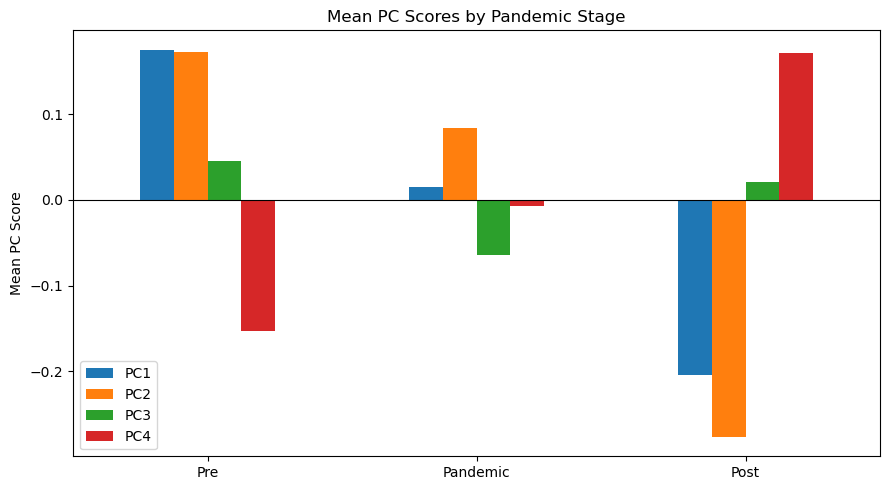

In [29]:
mean_pc.plot(kind='bar', figsize=(9, 5), legend=True)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Mean PC Scores by Pandemic Stage')
plt.ylabel('Mean PC Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The bar chart shows how mean scores for each principal component shifted across the three pandemic stages.
PC1 (Intensity) and PC2 (Vocal Style) both declined steadily from Pre to Post, with the sharpest drop in the Post stage. This suggests mainstream music became less intense and less rap-dominated over time.
PC3 (Instrumentalness) dipped during the pandemic and partially recovered in the Post stage, indicating a temporary shift away from instrumental tracks during lockdowns.
PC4 (Positive Vocal) shows the opposite trend — negative in the Pre stage, near zero during the pandemic, and rising sharply in the Post stage. This points to a growing preference for emotionally positive, non-rap vocal music in the post-pandemic period.

### PC Score Trends Over Time (Annual)

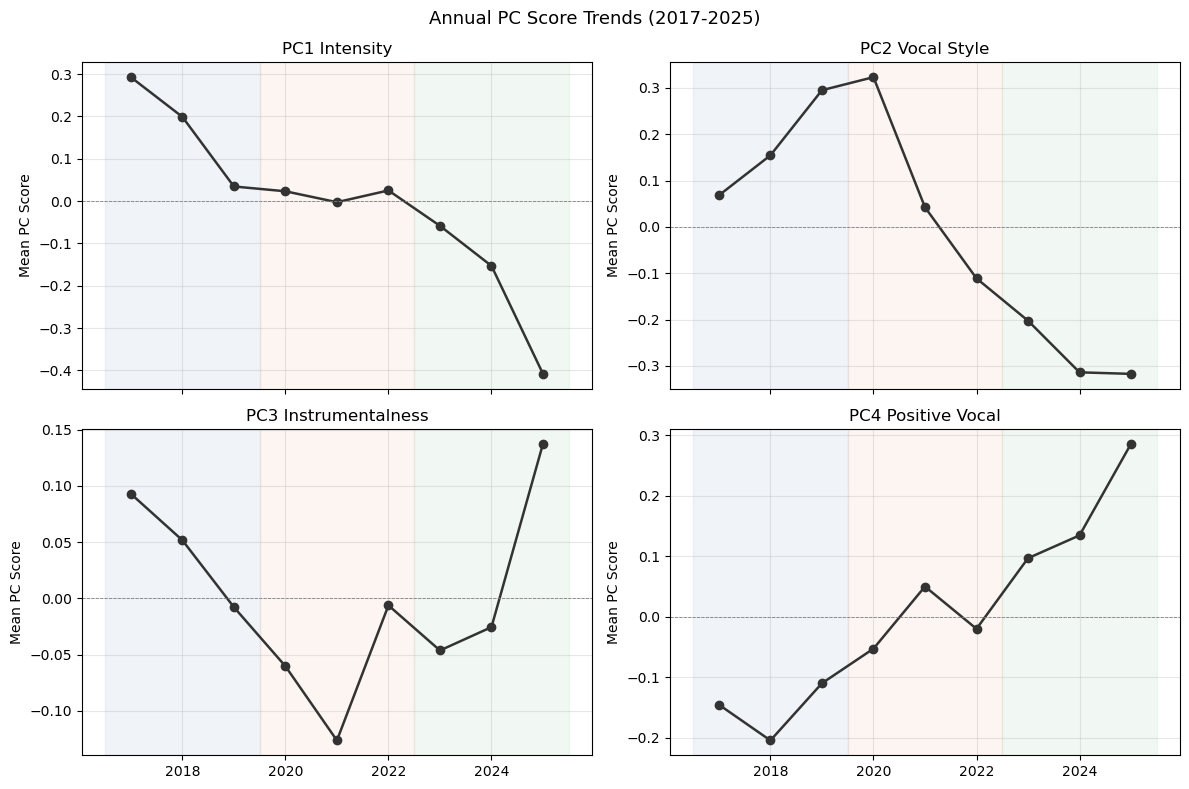

In [27]:
annual_pc = df.groupby('Year')[pcs].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for i, pc in enumerate(pcs):
    axes[i].plot(annual_pc['Year'], annual_pc[pc], marker='o', color='#333333', linewidth=1.8)
    axes[i].axvspan(2016.5, 2019.5, alpha=0.08, color='#4C72B0')
    axes[i].axvspan(2019.5, 2022.5, alpha=0.08, color='#DD8452')
    axes[i].axvspan(2022.5, 2025.5, alpha=0.08, color='#55A868')
    axes[i].axhline(0, color='gray', linewidth=0.6, linestyle='--')
    axes[i].set_title(pc_labels[pc])
    axes[i].set_ylabel('Mean PC Score')
    axes[i].grid(alpha=0.3)

plt.suptitle('Annual PC Score Trends (2017-2025)', fontsize=13)
plt.tight_layout()
plt.show()

The line charts trace annual mean PC scores from 2017 to 2025, with shaded regions marking the three pandemic stages.

PC1 (Intensity) shows a steady long-term decline, dropping sharply after 2022 and reaching its lowest point in 2025. Mainstream music has consistently become less intense and electronically driven over the eight-year period.

PC2 (Vocal Style) rose through the pre-pandemic years, peaking around 2020-2021, then fell sharply through the post-pandemic period. This suggests rap and hip-hop dominated the early pandemic era but lost ground significantly afterward.

PC3 (Instrumentalness) dipped to its lowest point in 2021 during the height of the pandemic, then rebounded strongly in 2024-2025. This may reflect a renewed interest in instrumental or less vocal-heavy music in the post-pandemic period.

PC4 (Positive Vocal) followed the opposite pattern to PC2 — declining into the pandemic years and recovering steadily through 2023-2025, suggesting listeners increasingly favored emotionally positive, melodic vocal music as the pandemic receded.

### Cluster Distribution by Stage

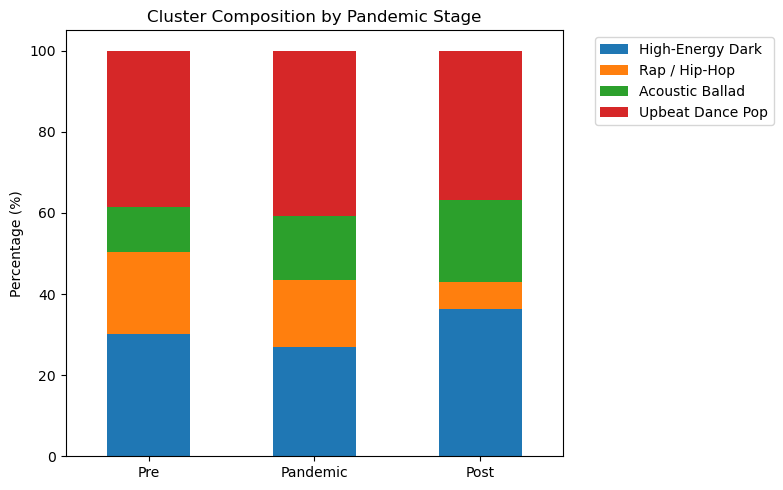

In [30]:
stage_cluster_pct.index = ['Pre', 'Pandemic', 'Post']
stage_cluster_pct.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Cluster Composition by Pandemic Stage')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

The stacked bar chart shows how the proportion of each music cluster shifted across the three pandemic stages.

Rap / Hip-Hop declined steadily from 20.19% in the pre-pandemic period to 6.89% in the post-pandemic period, representing the most dramatic shift among all clusters. This aligns with the PC2 trend observed earlier.

Acoustic Ballad grew consistently from 11.24% to 20.11%, suggesting listeners increasingly gravitated toward softer, more introspective music — a trend that accelerated rather than reversed after the pandemic.

Upbeat Dance Pop remained relatively stable across all three stages (38-41%), indicating it represents a persistent core of mainstream music consumption regardless of external disruptions.

High-Energy Dark dipped slightly during the pandemic but rebounded to its highest level (36.19%) in the post-pandemic period, suggesting a renewed appetite for intense, electronically driven music after lockdowns ended.

Overall, the distribution in the post-pandemic stage differs from both the pre-pandemic and pandemic periods, with the average distributional difference being slightly smaller between Post and Pandemic (0.0686) than between Post and Pre (0.0747), supporting a Continuation verdict for H2.